In [1]:
import os
from pathlib import Path
from itertools import combinations

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import NumericType

import pandas as pd
import matplotlib.pyplot as plt

### Configuration & Spark session

In [2]:
PROJECT_ROOT = Path(
    r"D:\Fourth Semester\Big Data\Project\Timetable-Based Bus Route Performance Analytics"
).resolve()
OUTPUT_DIR = Path(os.environ.get("OUTPUT_DIR", PROJECT_ROOT / "output"))
FINAL_PARQUET_PATH = str(OUTPUT_DIR / "final_schedule.parquet")

N_CORES = int(os.environ.get("SPARK_CORES", "8"))

spark = (
    SparkSession.builder
    .appName("BusRoute_03_EDA")
    .master(f"local[{N_CORES}]")
    .config("spark.sql.shuffle.partitions", str(N_CORES * 2))
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)
print("Spark UI     :", spark.sparkContext.uiWebUrl)

Spark version: 3.5.8
Spark UI     : http://DESKTOP-P7PE4MO:4040


### Load final dataset

In [3]:
schedule = spark.read.parquet(FINAL_PARQUET_PATH)
schedule = schedule.repartition(N_CORES * 2).cache()

BASE_ROWS = schedule.count()
print("Rows    :", f"{BASE_ROWS:,}")
print("Columns :", len(schedule.columns))
print("Partitions:", schedule.rdd.getNumPartitions())

assert BASE_ROWS > 0, "final_schedule.parquet loaded with zero rows -- check Notebook 02's output."
schedule.printSchema()

Rows    : 926,481
Columns : 16
Partitions: 16
root
 |-- line_ref: string (nullable = true)
 |-- source_file: string (nullable = true)
 |-- stop_point_ref: string (nullable = true)
 |-- vehicle_journey_code: string (nullable = true)
 |-- stop_sequence: integer (nullable = true)
 |-- scheduled_time: string (nullable = true)
 |-- scheduled_ts: timestamp (nullable = true)
 |-- service_ref: string (nullable = true)
 |-- line_name: string (nullable = true)
 |-- operator_ref: string (nullable = true)
 |-- journey_pattern_ref: string (nullable = true)
 |-- scheduled_departure_time: string (nullable = true)
 |-- scheduled_departure_ts: timestamp (nullable = true)
 |-- stop_name: string (nullable = true)
 |-- fare_publication_count: long (nullable = true)
 |-- has_fare_data: integer (nullable = true)



In [4]:
schedule.show(5, truncate=False)

+---------------------+------------------------------------------------------------------------------------------------------------+--------------+--------------------+-------------+--------------+-------------------+-------------+---------+------------+-------------------+------------------------+----------------------+-------------------------------+----------------------+-------------+
|line_ref             |source_file                                                                                                 |stop_point_ref|vehicle_journey_code|stop_sequence|scheduled_time|scheduled_ts       |service_ref  |line_name|operator_ref|journey_pattern_ref|scheduled_departure_time|scheduled_departure_ts|stop_name                      |fare_publication_count|has_fare_data|
+---------------------+------------------------------------------------------------------------------------------------------------+--------------+--------------------+-------------+--------------+-------------------

## Column typing (decided once, used everywhere below)

In [6]:
NUMERIC_COLUMNS = ["stop_sequence", "fare_publication_count", "has_fare_data"]
CATEGORICAL_COLUMNS = [
    "source_file",
    "vehicle_journey_code",
    "line_ref",
    "line_name",
    "service_ref",
    "operator_ref",
    "journey_pattern_ref",
    "stop_point_ref",
    "stop_name",
    "scheduled_time",
    "scheduled_departure_time",
]
TIMESTAMP_COLUMNS = ["scheduled_ts", "scheduled_departure_ts"]

declared = set(NUMERIC_COLUMNS + CATEGORICAL_COLUMNS + TIMESTAMP_COLUMNS)
actual_string_types = {
    f.name for f in schedule.schema.fields if not isinstance(f.dataType, NumericType)
} - set(TIMESTAMP_COLUMNS)


unclassified = actual_string_types - set(CATEGORICAL_COLUMNS)
assert not unclassified, f"Unclassified non-numeric column(s), add to CATEGORICAL_COLUMNS: {unclassified}"

print("Numeric columns    :", NUMERIC_COLUMNS)
print("Categorical columns:", CATEGORICAL_COLUMNS)
print("Timestamp columns  :", TIMESTAMP_COLUMNS)

Numeric columns    : ['stop_sequence', 'fare_publication_count', 'has_fare_data']
Categorical columns: ['source_file', 'vehicle_journey_code', 'line_ref', 'line_name', 'service_ref', 'operator_ref', 'journey_pattern_ref', 'stop_point_ref', 'stop_name', 'scheduled_time', 'scheduled_departure_time']
Timestamp columns  : ['scheduled_ts', 'scheduled_departure_ts']


## Data profiling

In [7]:
null_report = schedule.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in schedule.columns
]).collect()[0].asDict()

null_df = pd.DataFrame(
    [(c, n, round(100 * n / BASE_ROWS, 2)) for c, n in null_report.items()],
    columns=["Column", "Null Count", "Null %"],
).sort_values("Null Count", ascending=False)
print(null_df.to_string(index=False))

                  Column  Null Count  Null %
               stop_name      414980   44.79
                line_ref           0    0.00
          stop_point_ref           0    0.00
             source_file           0    0.00
           stop_sequence           0    0.00
          scheduled_time           0    0.00
            scheduled_ts           0    0.00
    vehicle_journey_code           0    0.00
             service_ref           0    0.00
               line_name           0    0.00
     journey_pattern_ref           0    0.00
            operator_ref           0    0.00
scheduled_departure_time           0    0.00
  scheduled_departure_ts           0    0.00
  fare_publication_count           0    0.00
           has_fare_data           0    0.00


In [8]:
natural_key = ["source_file", "vehicle_journey_code", "stop_point_ref", "stop_sequence"]
n_distinct_key = schedule.dropDuplicates(natural_key).count()
print("Total rows           :", f"{BASE_ROWS:,}")
print("Distinct on nat. key :", f"{n_distinct_key:,}")
print("Duplicate rows       :", f"{BASE_ROWS - n_distinct_key:,}")
assert BASE_ROWS == n_distinct_key, "Unexpected duplicates on the natural key."

Total rows           : 926,481
Distinct on nat. key : 926,481
Duplicate rows       : 0


In [9]:
cardinality = schedule.select([
    F.countDistinct(F.col(c)).alias(c) for c in CATEGORICAL_COLUMNS
]).collect()[0].asDict()

card_df = pd.DataFrame(cardinality.items(), columns=["Column", "Distinct Values"]) \
    .sort_values("Distinct Values", ascending=False)
print(card_df.to_string(index=False))

# A categorical column with exactly 1 distinct value is a constant column --
# flag it now so Notebook 04 knows to drop it rather than rediscovering this.
constant_categoricals = card_df[card_df["Distinct Values"] <= 1]["Column"].tolist()
if constant_categoricals:
    print(f"\n! Constant column(s) detected -- candidates to drop: {constant_categoricals}")
else:
    print("\nNo constant categorical columns found.")

                  Column  Distinct Values
          stop_point_ref             8830
               stop_name             5428
    vehicle_journey_code             3968
scheduled_departure_time             1219
          scheduled_time             1219
     journey_pattern_ref              251
             source_file              240
                line_ref              209
             service_ref              167
               line_name              116
            operator_ref                5

No constant categorical columns found.


In [10]:
sample_fraction = min(1.0, 2000 / BASE_ROWS)
sample_df = schedule.sample(withReplacement=False, fraction=sample_fraction, seed=42)

sample_pd = sample_df.select([
    F.date_format(F.col(c), "yyyy-MM-dd HH:mm:ss").alias(c) if c in TIMESTAMP_COLUMNS else F.col(c)
    for c in schedule.columns
]).toPandas()

estimated_size_mb = sample_pd.memory_usage(deep=True).sum() / len(sample_pd) * BASE_ROWS / 1024 / 1024
print(f"Sampled rows: {len(sample_pd):,} (fraction={sample_fraction:.4f})")
print(f"Estimated full dataset size: {estimated_size_mb:,.2f} MB")

Sampled rows: 1,982 (fraction=0.0022)
Estimated full dataset size: 854.74 MB


## Descriptive statistics 

In [11]:
schedule.select(NUMERIC_COLUMNS).describe().show(truncate=False)

+-------+------------------+----------------------+-------------------+
|summary|stop_sequence     |fare_publication_count|has_fare_data      |
+-------+------------------+----------------------+-------------------+
|count  |926481            |926481                |926481             |
|mean   |19.9051076060923  |0.7321715178184982    |0.7321715178184982 |
|stddev |15.558389601912463|0.44282795527303337   |0.44282795527303337|
|min    |0                 |0                     |0                  |
|max    |94                |1                     |1                  |
+-------+------------------+----------------------+-------------------+



In [12]:
agg_exprs = []
for c in NUMERIC_COLUMNS:
    agg_exprs += [
        F.variance(c).alias(f"{c}_variance"),
        F.skewness(c).alias(f"{c}_skewness"),
        F.kurtosis(c).alias(f"{c}_kurtosis"),
    ]
schedule.select(agg_exprs).show(truncate=False, vertical=True)

-RECORD 0----------------------------------------------
 stop_sequence_variance          | 242.06348700489787  
 stop_sequence_skewness          | 1.0084166069997011  
 stop_sequence_kurtosis          | 0.7341306940062311  
 fare_publication_count_variance | 0.19609659797129564 
 fare_publication_count_skewness | -1.0485862075846457 
 fare_publication_count_kurtosis | -0.9004669652632526 
 has_fare_data_variance          | 0.19609659797129564 
 has_fare_data_skewness          | -1.0485862075846457 
 has_fare_data_kurtosis          | -0.9004669652632526 



In [13]:
print("Median (50th percentile):")
for c in NUMERIC_COLUMNS:
    median = schedule.approxQuantile(c, [0.5], 0.01)[0]
    print(f"  {c:<30}: {median}")

print("\nMode (most frequent value):")
for c in NUMERIC_COLUMNS:
    mode_row = (
        schedule.groupBy(c).count()
        .orderBy(F.desc("count"))
        .first()
    )
    print(f"  {c:<30}: {mode_row[c]} (appears {mode_row['count']:,} times)")

Median (50th percentile):
  stop_sequence                 : 17.0
  fare_publication_count        : 1.0
  has_fare_data                 : 1.0

Mode (most frequent value):
  stop_sequence                 : 0 (appears 29,339 times)
  fare_publication_count        : 1 (appears 678,343 times)
  has_fare_data                 : 1 (appears 678,343 times)


In [14]:
pairs = list(combinations(NUMERIC_COLUMNS, 2))
corr_rows = []
for a, b in pairs:
    corr_rows.append((a, b, schedule.stat.corr(a, b)))

corr_df = pd.DataFrame(corr_rows, columns=["Feature A", "Feature B", "Pearson r"])
print(corr_df.to_string(index=False))

             Feature A              Feature B  Pearson r
         stop_sequence fare_publication_count   0.019275
         stop_sequence          has_fare_data   0.019275
fare_publication_count          has_fare_data   1.000000


In [15]:
outlier_summary = []
for c in NUMERIC_COLUMNS:
    q1, q3 = schedule.approxQuantile(c, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = schedule.filter((F.col(c) < lower) | (F.col(c) > upper)).count()
    outlier_summary.append((c, q1, q3, lower, upper, n_outliers, round(100 * n_outliers / BASE_ROWS, 2)))

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Column", "Q1", "Q3", "Lower Bound", "Upper Bound", "Outlier Count", "Outlier %"],
)
print(outlier_df.to_string(index=False))

                Column  Q1   Q3  Lower Bound  Upper Bound  Outlier Count  Outlier %
         stop_sequence 8.0 28.0        -22.0         58.0          23101       2.49
fare_publication_count 0.0  1.0         -1.5          2.5              0       0.00
         has_fare_data 0.0  1.0         -1.5          2.5              0       0.00


## Categorical, route, and operator analysis

In [16]:
top_routes = schedule.groupBy("line_ref").count().orderBy(F.desc("count"))
top_routes.show(20, truncate=False)

+---------------------+-----+
|line_ref             |count|
+---------------------+-----+
|SCGL:PH0005031:13:10 |44786|
|SCGL:PH0005031:205:55|25033|
|SCGL:PH0005031:180:A |22518|
|SCGL:PH0005031:176:8 |20350|
|SCCM:PF0000459:163:1 |18599|
|SCOX:PH0005863:12:1  |18568|
|SCCM:PF0000459:27:1  |17569|
|SCOX:PH0005863:16:S1 |15678|
|SCGL:PH0005031:39:71 |14346|
|SCGL:PH0005031:188:94|14190|
|SCGL:PH0005031:10:1  |13745|
|SCGL:PH0005031:186:41|13040|
|SCGL:PH0005031:291:64|13005|
|SCGL:PH0005031:182:C |12730|
|SCGL:PH0005031:209:S6|12604|
|SCGL:PH0005031:208:S6|12476|
|SCGL:PH0005031:194:7 |12130|
|SCOX:PH0005863:13:2  |11757|
|SCGL:PH0005031:167:22|11429|
|SCGL:PH0005031:183:D |11168|
+---------------------+-----+
only showing top 20 rows



In [17]:
schedule.groupBy("operator_ref").count().orderBy(F.desc("count")).show()

+------------+------+
|operator_ref| count|
+------------+------+
|           1|598852|
|          11|186878|
|           2| 65351|
|           4| 49557|
|           3| 25843|
+------------+------+



In [18]:
schedule.groupBy("stop_name").count().orderBy(F.desc("count")).show(20, truncate=False)

+----------------------------------+------+
|stop_name                         |count |
+----------------------------------+------+
|NULL                              |414980|
|Cowley The Original Swan          |1351  |
|Oxford City Centre Queens Lane    |1060  |
|Headington Headington Shops       |988   |
|Cowley Templars Square            |953   |
|Headington Headington School      |820   |
|Summertown Shops                  |811   |
|Kidlington Gosford Hill           |799   |
|Garden City                       |799   |
|Oxford City Centre High Street    |794   |
|Oxford City Centre Park End Street|770   |
|Oxford City Centre Westgate       |742   |
|Cowley Barns Road                 |741   |
|Oxford Manzil Way                 |741   |
|Cowley Marsh Road                 |741   |
|Oxford Howard Street east         |741   |
|Oxford James Street east          |741   |
|Oxford Shelley Road               |741   |
|Oxford The Plain                  |741   |
|Blackbird Leys Sandy Lane W    

## Time-of-day and peak-hour analysis

In [19]:
hourly = (
    schedule
    .withColumn("hour", F.hour("scheduled_ts"))
    .groupBy("hour")
    .count()
    .orderBy("hour")
)
hourly.show(24)

n_null_hour = schedule.withColumn("hour", F.hour("scheduled_ts")).filter(F.col("hour").isNull()).count()
print(f"\nRows with unparseable hour: {n_null_hour:,} ({100*n_null_hour/BASE_ROWS:.2f}%)")
assert n_null_hour / BASE_ROWS < 0.01, "More than 1% of rows have an unparseable scheduled_ts -- investigate before trusting hourly analysis."

+----+-----+
|hour|count|
+----+-----+
|   0| 7630|
|   1| 3411|
|   2| 2053|
|   3| 1194|
|   4| 3186|
|   5|15292|
|   6|36447|
|   7|48389|
|   8|56353|
|   9|64216|
|  10|64847|
|  11|67241|
|  12|66268|
|  13|66752|
|  14|66145|
|  15|64714|
|  16|63059|
|  17|59804|
|  18|48249|
|  19|33837|
|  20|26643|
|  21|23829|
|  22|20667|
|  23|16255|
+----+-----+


Rows with unparseable hour: 0 (0.00%)


In [20]:
schedule.withColumn(
    "hour", F.hour("scheduled_ts")
).withColumn(
    "period",
    F.when((F.col("hour").between(7, 9)) | (F.col("hour").between(16, 18)), "Peak")
     .otherwise("Off-Peak")
).groupBy("period").count().orderBy(F.desc("count")).show()

+--------+------+
|  period| count|
+--------+------+
|Off-Peak|586411|
|    Peak|340070|
+--------+------+



## Visualisations 

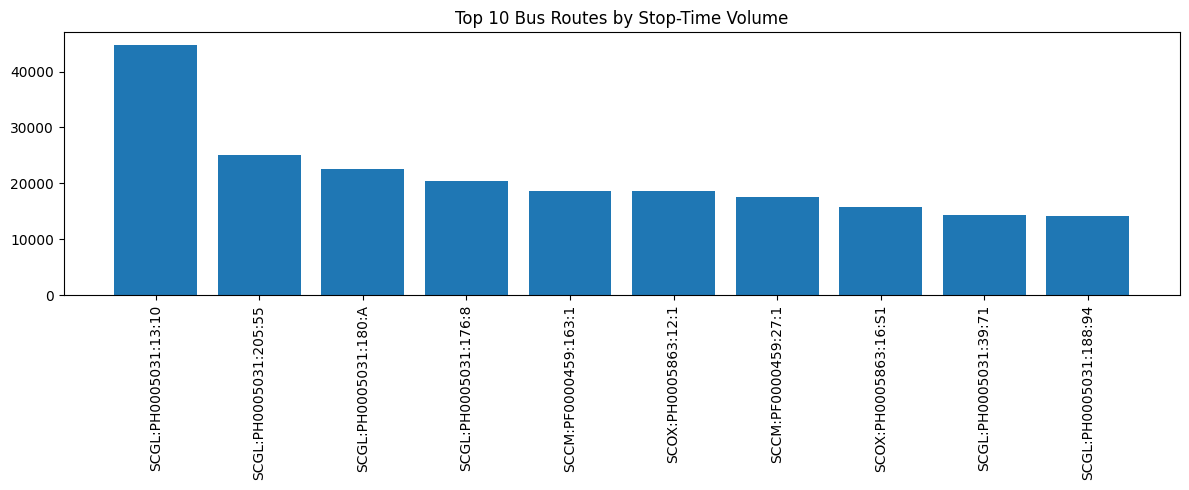

In [21]:
pdf = top_routes.limit(10).toPandas()
plt.figure(figsize=(12, 5))
plt.bar(pdf["line_ref"], pdf["count"])
plt.xticks(rotation=90)
plt.title("Top 10 Bus Routes by Stop-Time Volume")
plt.tight_layout()
plt.show()

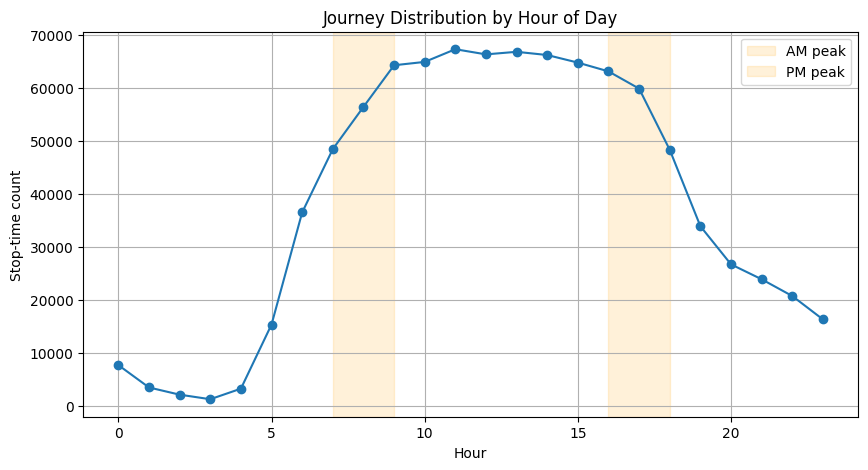

In [22]:
pdf = hourly.toPandas()
plt.figure(figsize=(10, 5))
plt.plot(pdf["hour"], pdf["count"], marker="o")
plt.axvspan(7, 9, alpha=0.15, color="orange", label="AM peak")
plt.axvspan(16, 18, alpha=0.15, color="orange", label="PM peak")
plt.legend()
plt.grid(True)
plt.title("Journey Distribution by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Stop-time count")
plt.show()

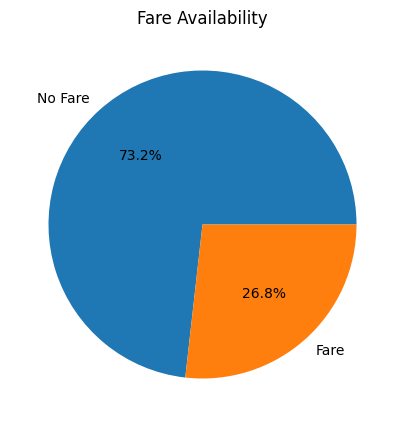

In [23]:
fare_plot = schedule.groupBy("has_fare_data").count().toPandas()
plt.figure(figsize=(5, 5))
plt.pie(fare_plot["count"], labels=["No Fare", "Fare"], autopct="%1.1f%%")
plt.title("Fare Availability")
plt.show()

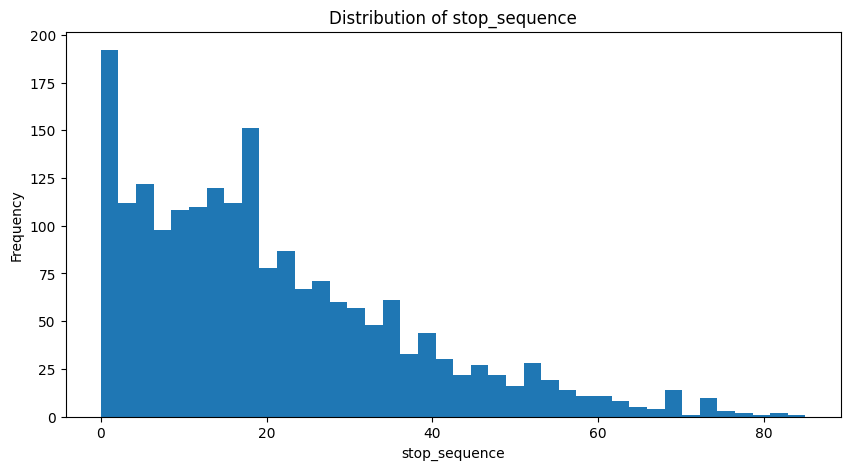

In [24]:
pdf = schedule.select("stop_sequence").sample(fraction=sample_fraction, seed=42).toPandas()
plt.figure(figsize=(10, 5))
plt.hist(pdf["stop_sequence"], bins=40)
plt.title("Distribution of stop_sequence")
plt.xlabel("stop_sequence")
plt.ylabel("Frequency")
plt.show()

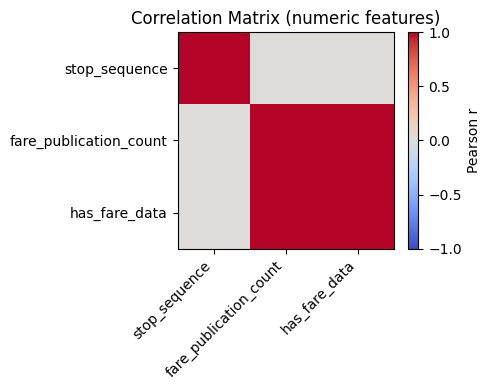

In [25]:
import numpy as np

corr_matrix = pd.DataFrame(
    np.eye(len(NUMERIC_COLUMNS)), index=NUMERIC_COLUMNS, columns=NUMERIC_COLUMNS
)
for _, row in corr_df.iterrows():
    corr_matrix.loc[row["Feature A"], row["Feature B"]] = row["Pearson r"]
    corr_matrix.loc[row["Feature B"], row["Feature A"]] = row["Pearson r"]

plt.figure(figsize=(5, 4))
plt.imshow(corr_matrix, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Pearson r")
plt.xticks(range(len(NUMERIC_COLUMNS)), NUMERIC_COLUMNS, rotation=45, ha="right")
plt.yticks(range(len(NUMERIC_COLUMNS)), NUMERIC_COLUMNS)
plt.title("Correlation Matrix (numeric features)")
plt.tight_layout()
plt.show()

In [26]:
schedule.createOrReplaceTempView("schedule")

In [27]:
spark.sql('''
    SELECT operator_ref, COUNT(*) AS journeys
    FROM schedule
    GROUP BY operator_ref
    ORDER BY journeys DESC
''').show()

+------------+--------+
|operator_ref|journeys|
+------------+--------+
|           1|  598852|
|          11|  186878|
|           2|   65351|
|           4|   49557|
|           3|   25843|
+------------+--------+



In [28]:
spark.sql('''
    SELECT has_fare_data, COUNT(*) AS total
    FROM schedule
    GROUP BY has_fare_data
''').show()

+-------------+------+
|has_fare_data| total|
+-------------+------+
|            1|678343|
|            0|248138|
+-------------+------+



In [29]:
spark.sql('''
    SELECT stop_name, COUNT(*) AS total
    FROM schedule
    GROUP BY stop_name
    ORDER BY total DESC
    LIMIT 20
''').show(truncate=False)

+----------------------------------+------+
|stop_name                         |total |
+----------------------------------+------+
|NULL                              |414980|
|Cowley The Original Swan          |1351  |
|Oxford City Centre Queens Lane    |1060  |
|Headington Headington Shops       |988   |
|Cowley Templars Square            |953   |
|Headington Headington School      |820   |
|Summertown Shops                  |811   |
|Kidlington Gosford Hill           |799   |
|Garden City                       |799   |
|Oxford City Centre High Street    |794   |
|Oxford City Centre Park End Street|770   |
|Oxford City Centre Westgate       |742   |
|Oxford James Street east          |741   |
|Cowley Barns Road                 |741   |
|Oxford Shelley Road               |741   |
|Blackbird Leys Sandy Lane W       |741   |
|Cowley Marsh Road                 |741   |
|Oxford Howard Street east         |741   |
|Oxford The Plain                  |741   |
|Oxford Manzil Way              

In [30]:
spark.stop()
print("Spark session stopped. Notebook 03 complete.")

Spark session stopped. Notebook 03 complete.
